<a href="https://colab.research.google.com/github/Anmolrbd/FDS_Lab/blob/main/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

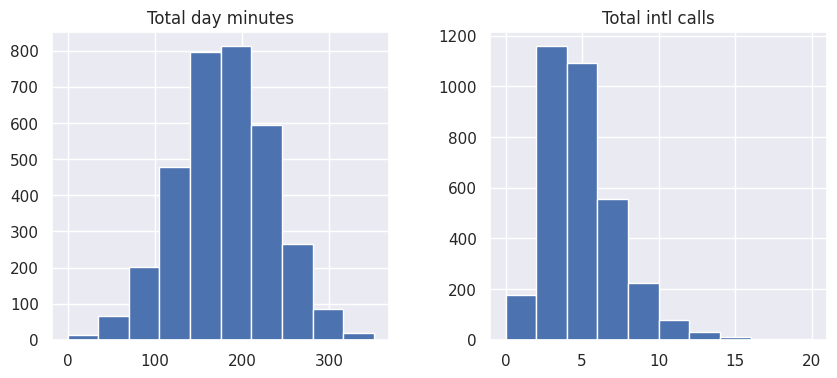

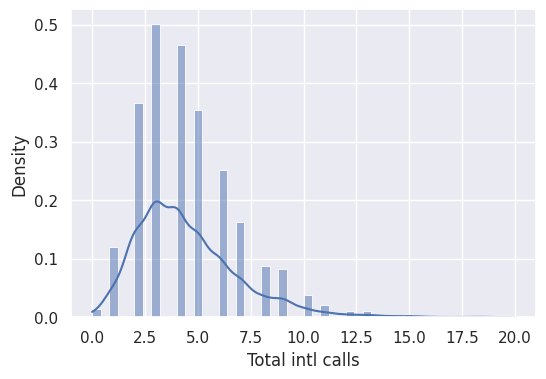

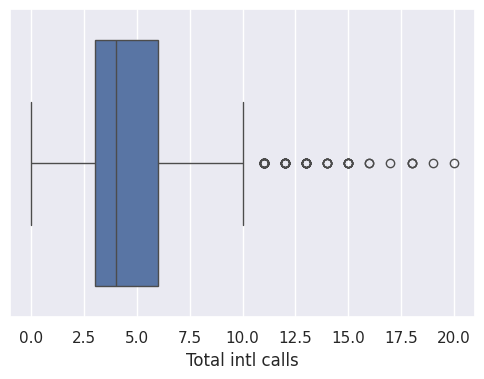

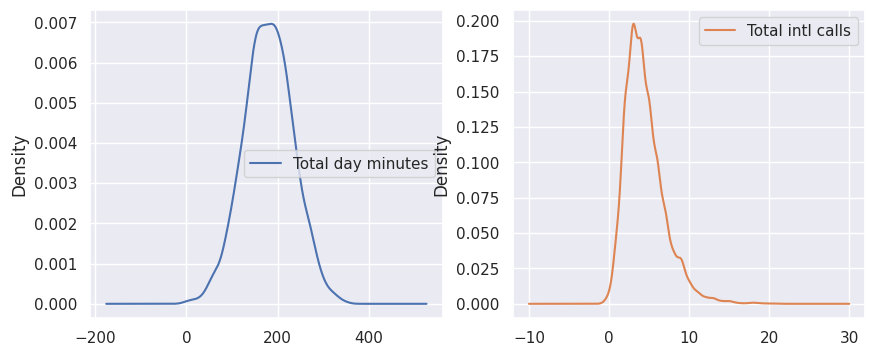

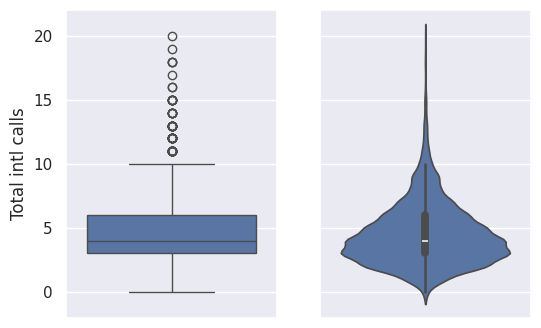

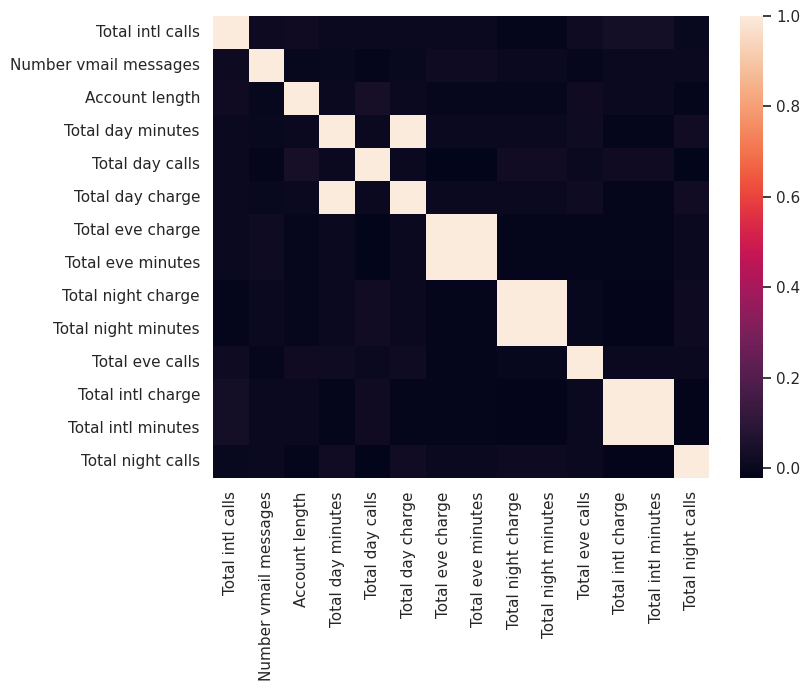

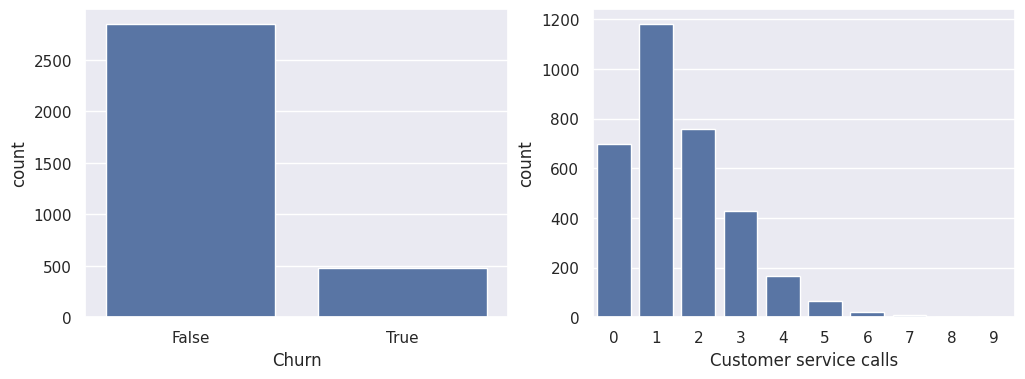

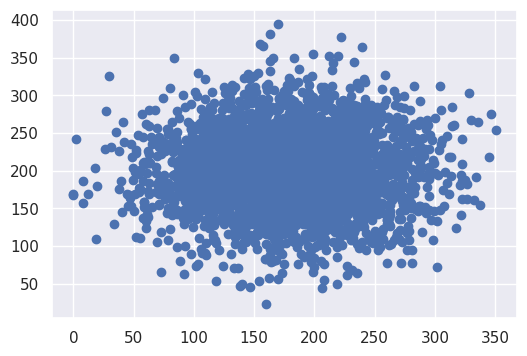

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

dataUrl = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/telecom_churn.csv"
df = pd.read_csv(dataUrl)

selectedFeatures = ["Total day minutes", "Total intl calls"]

df[selectedFeatures].hist(figsize=(10, 4))

plt.figure(figsize=(6, 4))
sns.histplot(df["Total intl calls"], kde=True, stat="density")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Total intl calls"])
plt.show()

df[selectedFeatures].plot(
    kind="density",
    subplots=True,
    layout=(1, 2),
    sharex=False,
    figsize=(10, 4)
)

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(6, 4))
sns.boxplot(data=df["Total intl calls"], ax=axes[0])
sns.violinplot(data=df["Total intl calls"], ax=axes[1])
plt.show()

numerical = list(
    set(df.columns) - set([
        "State",
        "International plan",
        "Voice mail plan",
        "Area code",
        "Churn",
        "Customer service calls"
    ])
)

corrMatrix = df[numerical].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corrMatrix)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Churn", data=df, ax=axes[0])
sns.countplot(x="Customer service calls", data=df, ax=axes[1])
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df["Total day minutes"], df["Total night minutes"])
plt.show()

sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="scatter")

numerical = list(
    set(numerical) - set([
        "Total day charge",
        "Total eve charge",
        "Total night charge",
        "Total intl charge"
    ])
)

sns.jointplot(
    x="Total day minutes",
    y="Total night minutes",
    data=df,
    kind="kde",
    color="g"
)

sns.pairplot(df[numerical])

numerical.append("Customer service calls")

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 7))

for idx, feat in enumerate(numerical):
    ax = axes[int(idx / 4), idx % 4]
    sns.boxplot(x="Churn", y=feat, data=df, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(feat)

plt.tight_layout()

sns.lmplot(
    x="Total day minutes",
    y="Total night minutes",
    data=df,
    hue="Churn",
    fit_reg=False
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x="Churn", y="Total day minutes", data=df, ax=axes[0])
sns.violinplot(x="Churn", y="Total day minutes", data=df, ax=axes[1])
plt.show()

sns.catplot(
    x="Churn",
    y="Total day minutes",
    col="Customer service calls",
    data=df[df["Customer service calls"] < 8],
    kind="box",
    col_wrap=4,
    height=3,
    aspect=0.8
)

sns.countplot(x="Customer service calls", hue="Churn", data=df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="International plan", hue="Churn", data=df, ax=axes[0])
sns.countplot(x="Voice mail plan", hue="Churn", data=df, ax=axes[1])
plt.show()

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X = df.drop(["Churn", "State"], axis=1)
X["International plan"] = X["International plan"].map({"Yes": 1, "No": 0})
X["Voice mail plan"] = X["Voice mail plan"].map({"Yes": 1, "No": 0})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(random_state=17)
tsneRepr = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(
    tsneRepr[:, 0],
    tsneRepr[:, 1],
    c=df["Churn"].map({False: "blue", True: "orange"}),
    alpha=0.5
)
plt.show()